In [15]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import seaborn as sn
import yfinance as yf

In [16]:
# S - 1 - fetch data of last 3 years
apple=  yf.download(tickers='AAPL',start='2021-07-19',end='2024-07-19')
tesla = yf.download(tickers='TSLA',start='2021-07-19',end='2024-07-19')

[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


In [17]:
# S - 2 Describe
apple['Close'].describe()

Ticker,AAPL
count,755.000000
mean,164.027595
std,20.275947
min,123.046806
25%,146.439781
50%,164.318008
75%,177.106209
max,233.017853


In [18]:
tesla['Close'].describe()

Ticker,TSLA
count,755.000000
mean,239.273073
std,59.473147
min,108.099998
25%,190.195000
50%,237.919998
75%,274.116669
max,409.970001


In [19]:
# S - 3 Compare with TradingView
pct_apple = apple['Close'].iloc[:, 0].pct_change()
pct_tesla = tesla['Close'].iloc[:, 0].pct_change()


<Axes: xlabel='AAPL', ylabel='Count'>

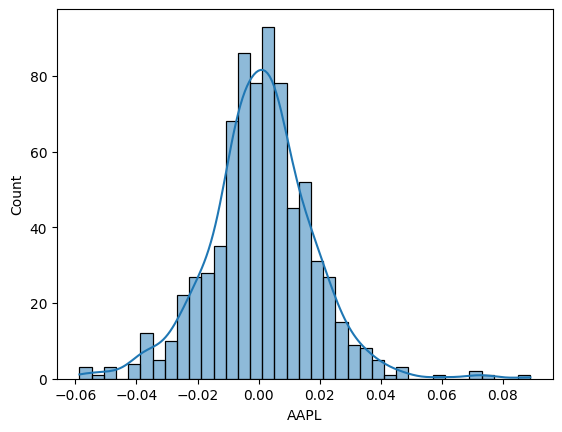

In [20]:
sn.histplot(pct_apple,kde=True)

<Axes: xlabel='TSLA', ylabel='Count'>

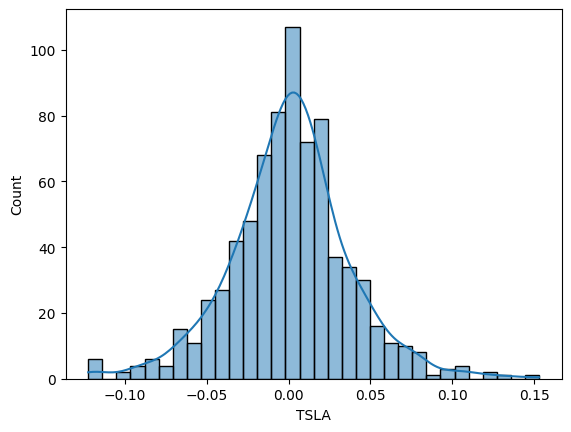

In [21]:
sn.histplot(pct_tesla,kde=True)

<Axes: ylabel='Count'>

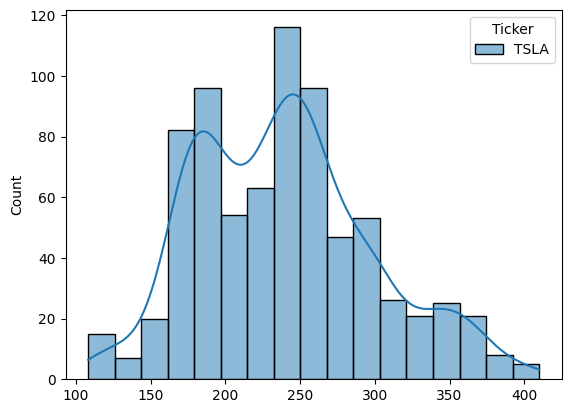

In [22]:
# S - 4 Draw histogram with close price and close price pct sn.histplot
sn.histplot(tesla['Close'],kde = True)

In [23]:
# S -5 - Find the CDF normal distribution

pct_apple.describe()

count    754.000000
mean       0.000773
std        0.017268
min       -0.058679
25%       -0.008429
50%        0.000776
75%        0.009983
max        0.088975
Name: AAPL, dtype: float64

In [24]:
pct_tesla.describe()

count    754.000000
mean       0.000866
std        0.036682
min       -0.122422
25%       -0.019141
50%        0.001642
75%        0.020187
max        0.153069
Name: TSLA, dtype: float64

In [25]:
cdf_apple = norm.cdf(pct_apple,loc=0.000750,scale=0.017268)
cdf_tesla = norm.cdf(pct_tesla,loc=0.000866,scale=0.036682)

In [26]:
# S - 6  - Find the CDF standard normal distribution

z_apple= (pct_apple - pct_apple.mean())/pct_apple.std()
z_tesla = (pct_tesla - pct_tesla.mean())/pct_tesla.std()

In [27]:
scdf_apple = norm.cdf(z_apple)
scdf_tesla = norm.cdf(z_tesla)

In [28]:
pd.Series(cdf_apple)

0           NaN
1      0.927955
2      0.366709
3      0.696422
4      0.742429
         ...   
750    0.761876
751    0.822824
752    0.524058
753    0.065734
754    0.108859
Length: 755, dtype: float64

In [29]:
sd_apple = pd.Series(scdf_apple)

In [30]:
pd.Series(cdf_tesla)

0           NaN
1      0.718640
2      0.405690
3      0.391863
4      0.393388
         ...   
750    0.785451
751    0.677497
752    0.655194
753    0.189419
754    0.522518
Length: 755, dtype: float64

In [31]:
sd_tesla = pd.Series(scdf_tesla)

<Axes: xlabel='AAPL', ylabel='Count'>

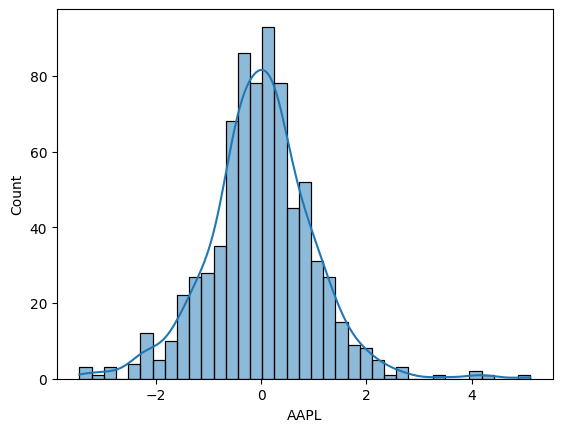

In [32]:
sn.histplot(z_apple,kde=True)

<Axes: xlabel='TSLA', ylabel='Count'>

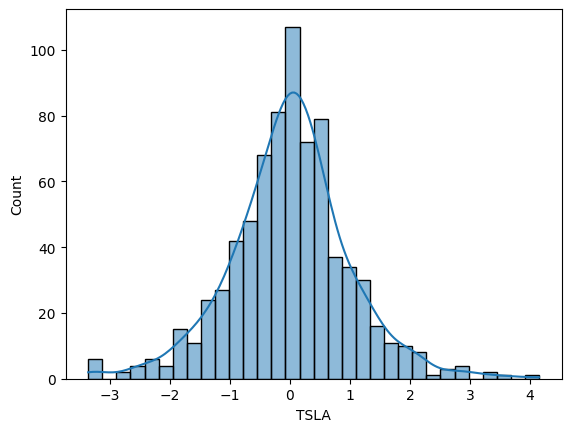

In [33]:
sn.histplot(z_tesla,kde=True)